<a href="https://colab.research.google.com/github/rodrigopazm96/Modern-Methods-in-Applied-Statistics/blob/main/Paz_hw7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework 7: Neural networks and variational autoencoders (VAEs)**
STAT 348, UChicago, Spring 2026

----------------
**Your name here:** Rodrigo Paz

**Hours spent:** 9h

(Please let us know how many hours in total you spent on this assignment so we can calibrate for future assignments. Your feedback is always welcome!)

----------------

<a href="https://colab.research.google.com/github/aschein/stat_348_2026/blob/main/assignments/hw7/hw7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

## Instructions

This homework focuses on themes in lecture 14 on neural networks, automatic differentiation, variational autoencoders, and amortized variational inference.

For this homework you will have to learn how to build and train neural networks using automatic differentiation in PyTorch, and then use them to build a variational autoencoder. There are many resources available to you online including:
- [Neural networks in PyTorch](https://docs.pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html)
- [A gentle introduction to torch.autograd](https://docs.pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html)
- [This notebook on neural networks and VAEs](https://github.com/slinderman/stats305c/blob/spring2023/notebooks/12_nns_vaes.ipynb)

For reference, this homework is a close adaption of [HW6 for Scott Linderman's STATS 305C](https://github.com/slinderman/stats305c/blob/spring2023/assignments/hw6/hw6.ipynb).

Assignment is due **Sunday May 24, 11:59pm** on GradeScope.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal, Bernoulli, Uniform
from torch.distributions.kl import kl_divergence
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.utils import make_grid
from torchvision import datasets
from torchvision.transforms import ToTensor
import torchvision.transforms as transforms

import numpy as np
import math
from tqdm.notebook import tqdm

torch.manual_seed(305)

import matplotlib.pyplot as plt
from matplotlib.cm import Blues
import seaborn as sns
sns.set_context("notebook")

## Problem 1: Optimizing a Quadratic Objective via Gradient Descent

We'll start off by optimizing a simple objective using gradient descent. We will compute the required gradients using **PyTorch's automatic differentation** capabilities.

Consider the function $f: \mathbb{R}^D \to \mathbb{R}$ given by:

$$ f(\mathbf{x}) = \mathbf{x}^\top \mathbf{A} \mathbf{x} $$

where $\mathbf{A} \in \mathbb{R}^{D \times D}$ is a fixed positive definite matrix. It is obvious that a global minimizer of $f$ is $\mathbf{x}^* = 0$. We will try to recover this known global minimizer using gradient descent. We note that although the objective is seemingly simple, a stochastic version of this objective has been used as a model for neural network loss surfaces (e.g. see [this paper](https://arxiv.org/abs/1803.02021)).

We will simplify the objective further by assuming that $\mathbf{A}$ is diagonal, so $\mathbf{A} = \text{diag}(\mathbf{a})$ for some $\mathbf{a} \in \mathbb{R}_{+}^D$.

### Problem 1a: Gradient descent with a well-conditioned objective

Recall the gradient descent update rule for a fixed step size $\alpha$ is:

$$\mathbf{x}^{(k + 1)} \gets \mathbf{x}^{(k)} - \alpha \nabla f(\mathbf{x}^{(k)})$$

Using PyTorch's automatic differentiation system, complete the function below implementing an optimization loop to minimize the objective.

In [3]:
def f(x, a):
    """ Evaluates the objective.

    Args:
        x: (D,) tensor
        a: (D,) tensor of positive values
    Returns:
        value: (,) tensor
    """
    return (a * x**2).sum()

def run_optimization(x, a, optimizer, num_iters):
    """ Runs an optimization algorithm on the objective for num_iters.

    Args:
        x: Starting position for optimization. nn.Parameter of shape (D,)
        a: parameter defining curvature of objective. tensor of shape (D,)
        optimizer: a torch.optim Optimizer
        num_iters: number of iterations to run optimization for

    Returns:
        xs: value of x at each iteration. tensor of shape (num_iters + 1, D)
        losses: value of objective at each iterate. tensor of shape (num_iters + 1,)
    """
    losses = []
    # we have to make a copy of the data so that elements of list do not
    # reference same location in memory
    xs = [x.data.clone()]

    for it in range(num_iters):
        optimizer.zero_grad()
        loss = f(x, a)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        xs.append(x.data.clone())

    # Return the stacked losses and xs
    losses = torch.tensor(losses)
    xs = torch.vstack(xs)
    return xs, losses

We will now run gradient descent on the objective in $D = 2$ dimensions, with $\mathbf{a} = (0.2, 0.2)$. We will use 50 iterations with a learning rate of $\alpha = 0.8$, starting from $\mathbf{x}_0 = (10, 10)$.

Note that we initialize `x` using `nn.Parameter`, which tells PyTorch we need to compute gradients with respect to `x`. Note that PyTorch's optimizers expect an iterable of `Parameters` to be passed as the first argument, so you must pass in `[x]` rather than `x` itself.

In [4]:
D = 2
x = nn.Parameter(10 * torch.ones(D))
a = 0.2 * torch.ones(D)

optimizer = optim.SGD([x], lr=0.8)
xs, losses = run_optimization(x, a, optimizer, num_iters=50)

Let's plot the loss curve. As you can see, the objective approaches the optimal value of zero quite quickly.

Text(0, 0.5, 'Objective Value')

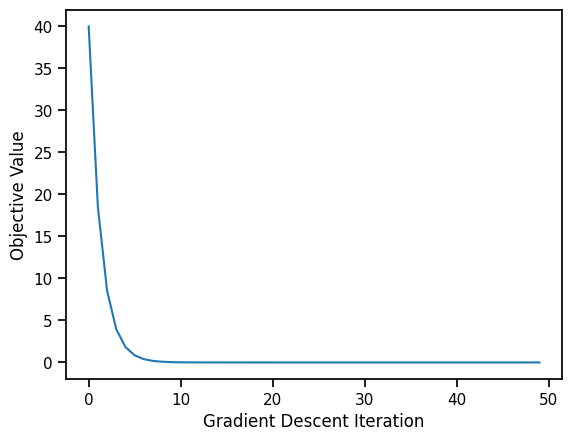

In [5]:
plt.figure()
plt.plot(losses)
plt.xlabel("Gradient Descent Iteration")
plt.ylabel("Objective Value")

Next, let's visualize the trajectory of the gradient descent iterates $\mathbf{x}^{(k)}$.

In [6]:
def visualize_gradient_descent(xs, a, width=12, grid_size=200):
    """ Visualizes gradient descent when iterates are two-dimensional."""

    def batch_f(X):
        """
        Args:
            X: (N, D) tensor
        """
        return (X**2 * a).sum(dim=1)

    grid_size = 200
    x1s = np.linspace(-width, width, grid_size)
    x2s = np.linspace(-width, width, grid_size)
    X1, X2 = np.meshgrid(x1s, x2s)
    points = np.transpose([np.tile(x1s, len(x2s)), np.repeat(x2s, len(x1s))])
    points = torch.tensor(points, dtype=torch.float)

    Z = batch_f(points).reshape(grid_size, grid_size)

    fig = plt.figure(figsize = (10,7))
    contours = plt.contour(X1, X2, Z, 20)

    plt.plot(xs[:,0], xs[:,1])
    plt.plot(xs[:,0], xs[:,1], '*', label = "Cost function")

    plt.xlabel('$x_1$', fontsize=15)
    plt.ylabel('$x_2$', fontsize=15)
    plt.show()

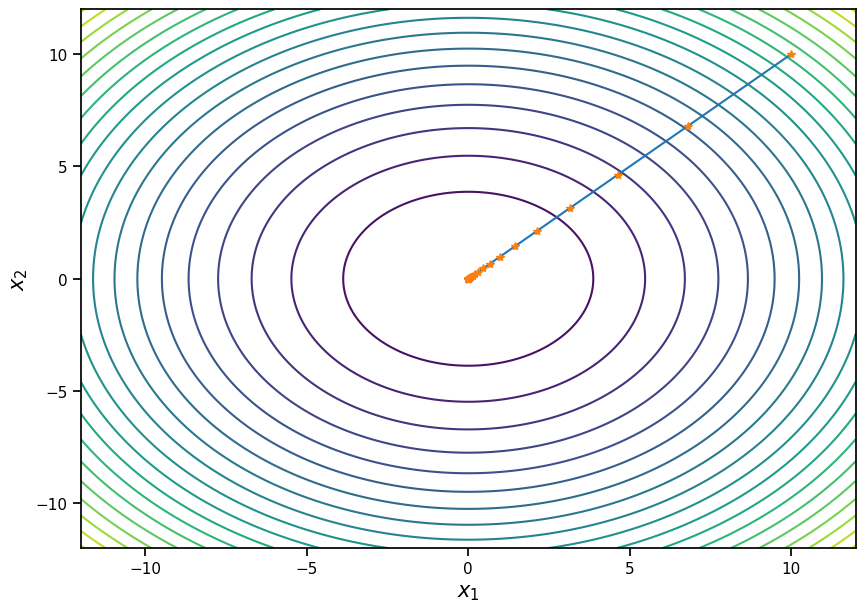

In [7]:
visualize_gradient_descent(xs, a)

### Problem 1b: Gradient Descent with an ill-conditioned objective

Next, let's see how gradient descent performs on an ill-conditioned objective, where the amount of curvature in each direction varies. For our objective, we can control the amount of curvature using $\mathbf{a}$. Repeat part (a), this time using $\mathbf{a} = (0.05, 1.2)$ while holding all other hyperparameters constant.

In [11]:
x = nn.Parameter(10 * torch.ones(D))
a = torch.tensor([0.05, 1.2])

optimizer = optim.SGD([x], lr=0.8)
xs, losses = run_optimization(x, a, optimizer, num_iters=50)

Text(0, 0.5, 'Objective Value')

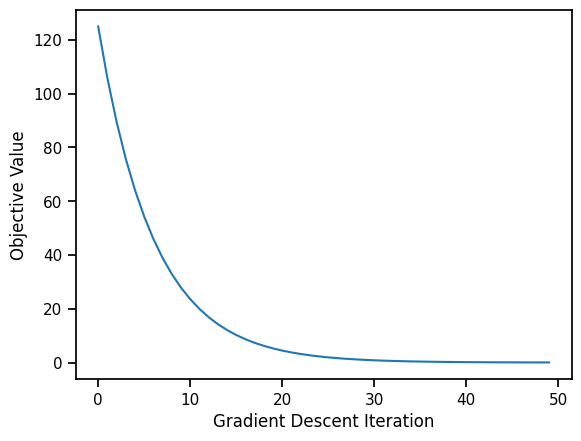

In [12]:
plt.figure()
plt.plot(losses)
plt.xlabel("Gradient Descent Iteration")
plt.ylabel("Objective Value")

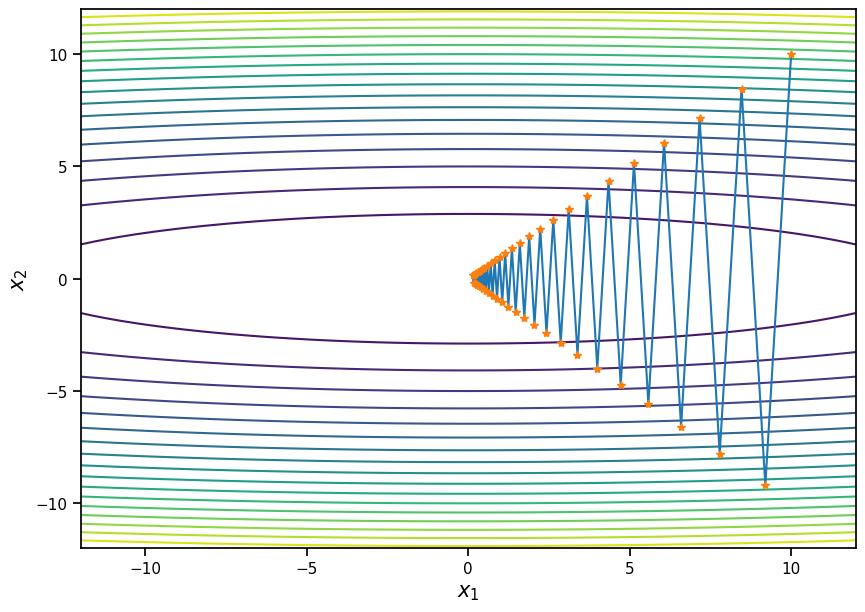

In [13]:
visualize_gradient_descent(xs, a)

Explain why the gradient descent iterates oscillate around the line $\mathbf{x}_2 = 0$ and suggest one change that could be made to eliminate this behavior, without changing the objective itself.

---

The gradient descent iterates oscillate around x_2 = 0 because the curvature in that direction is much larger than in the x1​ direction. With a2=1.2 and a learning rate of 0.80, the step size is too large relative to the curvature. The update overshoots zero, lands on the other side, overshoots again, and keeps bouncing. Meanwhile, x1​ converges smoothly because a1​=0.05 gives much flatter curvature, so the same learning rate is well suited for that direction.
The fix, without changing the objective, is to use an optimizer with adaptive per-dimension learning rates, like Adam or RMSProp. These methods track the magnitude of past gradients for each dimension separately and shrink the effective step size in directions with large, consistent gradients. That is exactly what is needed to tame the steep x2​ direction without slowing down progress in x1​.

---

### Problem 1c: Optimizing a High-Dimensional Objective

Now let's tackle a more challenging, higher-dimensional problem. We'll use the same objective, but this time use $\mathbf{a} \in \mathbb{R}^{10}$ where:

$$a_i = 10^{-2 + \frac{4(i - 1)}{9}}$$

for $i \in \{1, \dots, 10\}$. This means the curvature of the dimensions ranges from $0.01$ to $100$.

Experiment with different optimizers and hyperparameter settings on this problem, starting from the initial point $x^{(0)} = (10, \dots, 10)$ and run your chosen optimizer for $1000$ iterations. You can see a complete list of optimizers PyTorch has implemented [here](https://pytorch.org/docs/stable/optim.html#algorithms). Find an optimizer/hyperparameter regime that achieves a final loss of less than $0.01$.

In [14]:
x = nn.Parameter(10 * torch.ones(10))
a = torch.tensor([10**i for i in np.linspace(-2, 2, num=10)])

optimizer = optim.Adam([x], lr=0.1)
xs, losses = run_optimization(x, a, optimizer, num_iters=1000)

Text(0, 0.5, 'Objective Value')

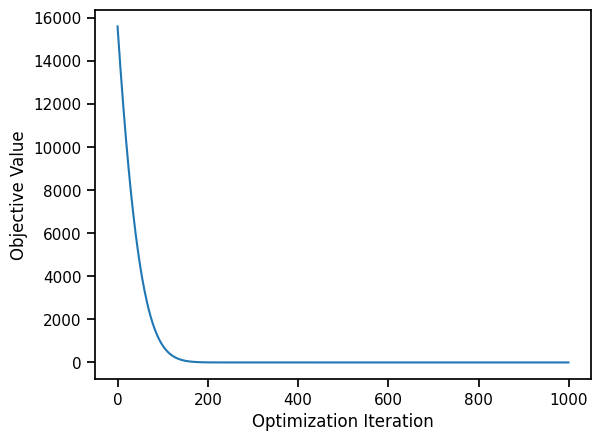

In [15]:
plt.figure()
plt.plot(losses)
plt.xlabel("Optimization Iteration")
plt.ylabel("Objective Value")

In [16]:
print("Final loss: {:.10f}".format(losses[-1].item()))

Final loss: 0.0000000000


## Problem 2: Neural Network Classification

Next, we will use a neural network to solve a classification problem for which the data is not linearly separable. We will implement the network as a PyTorch `nn.module` and train it using gradient descent, computing gradients using automatic differentation.

First, we create and visualize a two-dimensional dataset where each point is labeled as positive (1) or negative (0). As seen below, the positive and negative points are not linearly separable.


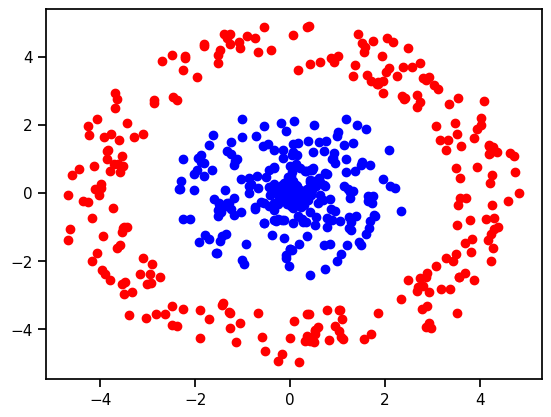

In [17]:
torch.manual_seed(305)

def make_dataset(num_points):
    radius = 5

    def sample_annulus(inner_radius, outer_radius, num_points):
        r = Uniform(inner_radius, outer_radius).sample((num_points,))
        angle = Uniform(0, 2 * math.pi).sample((num_points,))
        x = r * torch.cos(angle)
        y = r * torch.sin(angle)
        data = torch.vstack([x, y]).T
        return data

    # Generate positive examples (labeled 1)
    data_1 = sample_annulus(0, 0.5 * radius, num_points // 2)
    labels_1 = torch.ones(num_points // 2)

    # Generate negative examples (labeled 0).
    data_0 = sample_annulus(0.7 * radius, radius, num_points // 2)
    labels_0 = torch.zeros(num_points // 2)

    data = torch.vstack([data_0, data_1])
    labels = torch.concat([labels_0, labels_1])

    return data, labels

num_data = 500
data, labels = make_dataset(num_data)

# Note: red indicates a label of 1, blue indicates a label of 0
plt.scatter(data[:num_data//2, 0], data[:num_data//2, 1], color='red')
plt.scatter(data[num_data//2:, 0], data[num_data//2:, 1], color='blue')

### Problem 2a: The Maximum Likelihood Objective

We will try to classify this data using a neural network. We posit the following statistical model for the labels $y \in \{0, 1\}$ given features $\mathbf{x} \in \mathbb{R}^2$:

$$ y \mid x \sim \text{Bern}(\sigma(\text{NN}_{\boldsymbol{\theta}}(\mathbf{x})))$$

Here, $\text{NN}_{\boldsymbol{\theta}}: \mathbb{R}^2 \to \mathbb{R}$ denotes a neural network with parameters $\boldsymbol{\theta} \in \mathbb{R}^P$ mapping datapoints $\mathbf{x}$ to $\text{logit}(\mathbb{P}(y = 1 \mid \mathbf{x}))$. Recall the [logit](https://en.wikipedia.org/wiki/Logit) function is given by

$$\text{logit}(p) = \log \left( \frac{p}{1-p} \right)$$

and its inverse is the [sigmoid](https://en.wikipedia.org/wiki/Sigmoid_function):

$$\sigma(x) = \frac{1}{1 + \exp (-x)}$$

We estimate the parameters $\boldsymbol{\theta}$ using maximum likelihood. Show that for a dataset $\{(\mathbf{x}_n, y_n)\}_{n=1}^N$ the negative log-likelihood objective, rescaled by the number of datapoints $N$, may be written as:

$$ L(\boldsymbol{\theta}) = \frac{1}{N} \sum_{n = 1}^N -y_n \log \sigma(\text{NN}_{\boldsymbol{\theta}}(\mathbf{x})) - (1 - y_n) \log (1 -
 \sigma(\text{NN}_{\boldsymbol{\theta}}(\mathbf{x}))) = \frac{1}{N} \sum_{n = 1}^N \ell(y, \text{NN}_{\boldsymbol{\theta}}(\mathbf{x}_n))
$$

where $\ell(y, x) = -y \log \sigma(x) - (1 - y) \log(1 - \sigma(x))$.

---

$$p(y \mid \mathbf{x}; \boldsymbol{\theta}) = \sigma(\text{NN}_{\boldsymbol{\theta}}(\mathbf{x}))^y \cdot (1 - \sigma(\text{NN}_{\boldsymbol{\theta}}(\mathbf{x})))^{1-y}$$

Taking the log:

$$\log p(y \mid \mathbf{x}; \boldsymbol{\theta}) = y \log \sigma(\text{NN}_{\boldsymbol{\theta}}(\mathbf{x})) + (1-y) \log(1 - \sigma(\text{NN}_{\boldsymbol{\theta}}(\mathbf{x})))$$

The log-likelihood over the full dataset is:

$$\log p(\{y_n\} \mid \{x_n\}; \boldsymbol{\theta}) = \sum_{n=1}^N y_n \log \sigma(\text{NN}_{\boldsymbol{\theta}}(\mathbf{x}_n)) + (1-y_n) \log(1 - \sigma(\text{NN}_{\boldsymbol{\theta}}(\mathbf{x}_n)))$$

Negating and rescaling by $N$ gives the objective:

$$L(\boldsymbol{\theta}) = \frac{1}{N} \sum_{n=1}^N -y_n \log \sigma(\text{NN}_{\boldsymbol{\theta}}(\mathbf{x}_n)) - (1-y_n) \log(1 - \sigma(\text{NN}_{\boldsymbol{\theta}}(\mathbf{x}_n)))$$

which is exactly $\frac{1}{N} \sum_{n=1}^N \ell(y_n, \text{NN}_{\boldsymbol{\theta}}(\mathbf{x}_n))$ as required.

---

### Problem 2b: Define the Neural Network

We will use a neural network with two hidden layers, the first of which has three hidden units and the second of which has five hidden units. The equations defining the output $z \in \mathbb{R}$ of our neural network given an input $\mathbf{x} \in \mathbb{R}^2$ are:

$$
\begin{align*}
\mathbf{h}_1 &= \text{ReLU}(\mathbf{W_1} \mathbf{x} + \mathbf{b_1}) \\
\mathbf{h}_2 &= \text{ReLU}(\mathbf{W_2} \mathbf{h}_1 + \mathbf{b_2}) \\
z &= \mathbf{w}_3^\top \mathbf{h}_2 + b_3
\end{align*}
$$

The parameters of the network are $\boldsymbol{\theta} = (\mathbf{W}_1, \mathbf{b}_1, \mathbf{W}_2, \mathbf{b}_2, \mathbf{w}_3, b_3)$ where $\mathbf{W}_1 \in \mathbb{R}^{3 \times 2}, \mathbf{b}_1 \in \mathbb{R}^3, \mathbf{W}_2 \in \mathbb{R}^{5 \times 3}, \mathbf{b}_2 \in \mathbb{R}^5, \mathbf{w}_3 \in \mathbb{R}^5$, and $b_3 \in \mathbb{R}$.

Implement this network as a PyTorch `nn.Module` using `nn.Linear` and `F.relu`.

In [18]:
class SimpleNet(nn.Module):

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 3)
        self.fc2 = nn.Linear(3, 5)
        self.fc3 = nn.Linear(5, 1)

    def forward(self, x):
        h1 = F.relu(self.fc1(x))
        h2 = F.relu(self.fc2(h1))
        logits = self.fc3(h2).squeeze(-1)
        return logits

Let's visualize the predictions of an untrained network. As we can see, the network does not succeed at classifying the points without training



/tmp/ipykernel_5514/4058167085.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.pcolormesh(X1, X2, probs, cmap=plt.cm.get_cmap('YlGn'), vmin=0, vmax=1)


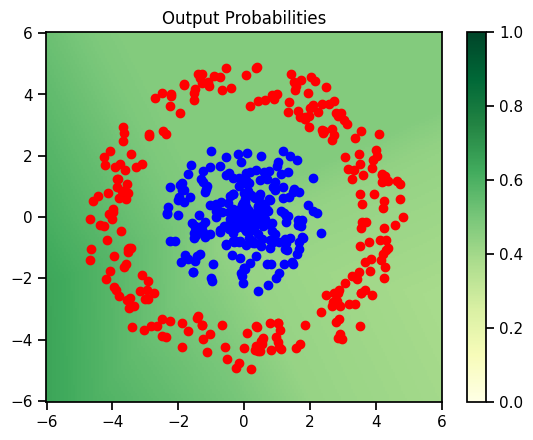

In [19]:
def visualize_predictions(net):
    num_points = 200
    x1s = np.linspace(-6.0, 6.0, num_points)
    x2s = np.linspace(-6.0, 6.0, num_points)
    X1, X2 = np.meshgrid(x1s, x2s)

    points = np.transpose([np.tile(x1s, len(x2s)), np.repeat(x2s, len(x1s))])
    points = torch.tensor(points, dtype=torch.float)
    with torch.no_grad():
        probs = torch.sigmoid(net(points)).reshape(num_points, num_points)

    plt.pcolormesh(X1, X2, probs, cmap=plt.cm.get_cmap('YlGn'), vmin=0, vmax=1)
    plt.colorbar()
    plt.scatter(data[:num_data//2, 0], data[:num_data//2, 1], color='red')
    plt.scatter(data[num_data//2:, 0], data[num_data//2:, 1], color='blue')
    plt.title("Output Probabilities")

torch.manual_seed(305)
model = SimpleNet()
visualize_predictions(model)

### Problem 2c: Train the Network

We will now find the parameters of our network by maximizing the likelihood, or equivalently minimizing the negative log-likelihood. We will use full-batch gradient descent. That is, we will use the gradient $\nabla L(\boldsymbol{\theta})$ itself to update the parameters rather than a stochastic estimate of $\nabla L(\boldsymbol{\theta})$.

Use the SGD optimizer from `torch.optim` with a learning rate of $1$ and no momentum for 1000 iterations. Note that the function $\ell$ from above is implemented in PyTorch as [`nn.BCEWithLogitsLoss`](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html).

In [20]:
num_steps = 1000
losses = []

loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=1)
for it in tqdm(range(num_steps)):
    optimizer.zero_grad()
    logits = model(data)
    loss = loss_fn(logits, labels)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

  0%|          | 0/1000 [00:00<?, ?it/s]

Text(0, 0.5, 'Objective Value')

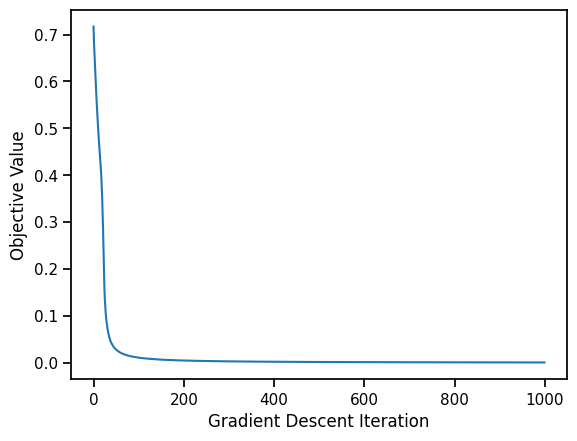

In [21]:
plt.figure()
plt.plot(losses)
plt.xlabel("Gradient Descent Iteration")
plt.ylabel("Objective Value")

Let's visualize the predictions of our trained network. We see that the network has learned to separate the positive and negative examples.

/tmp/ipykernel_5514/4058167085.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.pcolormesh(X1, X2, probs, cmap=plt.cm.get_cmap('YlGn'), vmin=0, vmax=1)


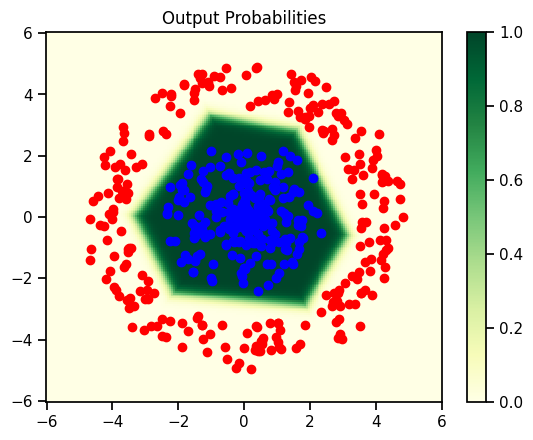

In [22]:
visualize_predictions(model)

## Problem 3: Amortized Variational Inference

In this problem, we will train a variational autoencoder for the MNIST dataset of handwritten digits. First, let's download this dataset using PyTorch's `datasets` module and visualize some of the digits. We will use a binarized version of the dataset in which each pixel value is either 0 or 1.

In [23]:
# Download MNIST dataset and create dataloaders.
def binarize(imgs, integer=False):
    threshold = 127 if integer else 0.5
    imgs = imgs.clone()
    imgs[imgs < threshold] = 0.
    imgs[imgs >= threshold] = 1.
    return imgs

train_dataset = datasets.MNIST(root="data", train=True, download=True,
                         transform=transforms.ToTensor())

test_dataset = datasets.MNIST(root='data', train=False, download=True,
                             transform=transforms.ToTensor())

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Number of points in dataset: {0}".format(train_dataset.data.shape[0]))
print("Number of batches per epoch: {0}".format(len(train_loader)))

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.74MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.84MB/s]

Number of points in dataset: 60000
Number of batches per epoch: 938


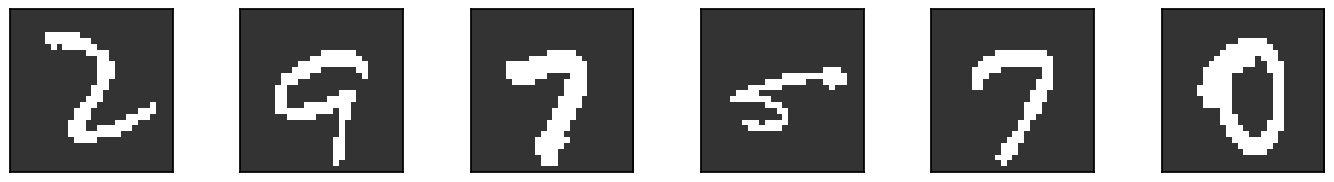

In [26]:
# Visualize some digits in the dataset.
imgs, _ = next(iter(train_loader))
imgs = binarize(imgs)
fig, ax = plt.subplots(1, 6, figsize=(14, 14))
fig.tight_layout()
for i, ax in enumerate(ax.flat):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(imgs[i].squeeze(), alpha=0.8, cmap='gray')

### Problem 3a: Decoder Network

We represent a $28 \times 28$ image $\mathbf{x}$ as a flattened $784$ dimensional vector of binary values, i.e. $\mathbf{x} \in \{0, 1\}^{784}$. We specify our generative model as:

$$ \mathbf{z} \sim \mathcal{N}(0, I), \quad \mathbf{x} \mid \mathbf{z} \sim \text{Bern}(\sigma(D_{\boldsymbol{\theta}}(\mathbf{z}))$$

Here, $D_{\boldsymbol{\theta}}: \mathbb{R}^2 \to \mathbb{R}^{784}$ is a neural network with parameters $\boldsymbol{\theta}$ and $\mathbf{z} \in \mathbb{R}^{2}$ is a two-dimensional latent variable. We use only two dimensions so that the latent space can be easily visualized later, but using a higher dimensional latent variable would give a more flexible generative model.

We will parametrize $D_{\boldsymbol{\theta}}$ as a fully connected neural network with two hidden layers and ReLU activations. We use 256 units in the first hidden layer and 512 in the second. Note that as in Problem 2, the network maps to the logits of the Bernoulli distribution and not the probabilities themselves. Implement this decoder network in PyTorch below.

In [27]:
# Define decoder architecture
class Decoder(nn.Module):
    """ Neural network defining p(x | z) """

    def __init__(self, data_dim, latent_dim, hidden_dims=[256, 512]):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim, hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.fc3 = nn.Linear(hidden_dims[1], data_dim)

    def forward(self, z):
        h1 = F.relu(self.fc1(z))
        h2 = F.relu(self.fc2(h1))
        logits = self.fc3(h2)
        return Bernoulli(logits=logits)

### Problem 3b: Encoder Network

We will estimate the parameters of the generative model by maximizing the Evidence Lower Bound (ELBO). As the exact posterior $p(\mathbf{z} \mid \mathbf{x})$ is unknown, we will use an approximate, amortized posterior $q_{\boldsymbol{\phi}}(\mathbf{z} \mid \mathbf{x}) = \mathcal{N}(\mathbf{z} \mid \mu_{\boldsymbol{\phi}}(\mathbf{x}), \text{diag}(\sigma^2_{\boldsymbol{\phi}}(\mathbf{x})))$. We let $\left(\mu_{\boldsymbol{\phi}}(\mathbf{x}), \log \sigma^2_{\boldsymbol{\phi}}(\mathbf{x}) \right) = E_{\boldsymbol{\phi}}(\mathbf{x})$ where $E_{\boldsymbol{\phi}}: \mathbb{R}^{784} \to \mathbb{R}^2 \times \mathbb{R}^2$ is a neural network with parameters $\boldsymbol{\phi}$.

As above, we parametrize $E_{\boldsymbol{\phi}}$ as a neural network with two layers of hidden units and ReLU activations. We use 512 hidden units in the first layer and 256 in the second. Then we let $\mu_{\boldsymbol{\phi}}$ and $\log \sigma^2_{\boldsymbol{\phi}}$ be affine functions of the hidden layer activations. Implement the encoder $E_{\boldsymbol{\phi}}$ in the code below.

In [28]:
# Define encoder architecture
class Encoder(nn.Module):
    """ Neural network defining q(z | x). """

    def __init__(self, data_dim, latent_dim, hidden_dims=[512, 256]):
        super().__init__()
        self.fc1 = nn.Linear(data_dim, hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.fc_mu = nn.Linear(hidden_dims[1], latent_dim)
        self.fc_logvar = nn.Linear(hidden_dims[1], latent_dim)

    def forward(self, x):
        h1 = F.relu(self.fc1(x))
        h2 = F.relu(self.fc2(h1))
        mu = self.fc_mu(h2)
        log_var = self.fc_logvar(h2)
        return Normal(mu, torch.exp(0.5 * log_var))

### ELBO Derivation [given]

As a function of $\boldsymbol{\theta}$ and $\boldsymbol{\phi}$, we can write the ELBO for a single datapoint $\mathbf{x}$ as:

$$\mathcal{L}(\mathbf{x}, \boldsymbol{\theta}, \boldsymbol{\phi}) = \mathbb{E}_{q_{\boldsymbol{\phi}}(\mathbf{z} \mid \mathbf{x})} \left[ \log p_{\boldsymbol{\theta}}(\mathbf{x}, \mathbf{z}) - \log q_{\boldsymbol{\phi}}(\mathbf{z} \mid \mathbf{x}) \right]$$

We can obtain a lower bound of the log-likelihood for an entire dataset $\{\mathbf{x}^{(n)} \}_{n=1}^N$, rescaled by the number of datapoints $N$, as:

$$\mathcal{L}(\boldsymbol{\theta}, \boldsymbol{\phi}) = \frac{1}{N} \sum_{n=1}^N \mathbb{E}_{q_{\boldsymbol{\phi}}(\mathbf{z}^{(n)} \mid \mathbf{x}^{(n)})} \left[ \log p_{\boldsymbol{\theta}}(\mathbf{x}^{(n)}, \mathbf{z}^{(n)}) - \log q_{\boldsymbol{\phi}}(\mathbf{z}^{(n)} \mid \mathbf{x}^{(n)}) \right]$$

We can rewrite the per-datapoint ELBO as:

$$
\begin{align*}
\mathcal{L}(\mathbf{x}, \boldsymbol{\theta}, \boldsymbol{\phi})
&= \mathbb{E}_{q_{\boldsymbol{\phi}}(\mathbf{z} \mid \mathbf{x})} \left[ \log p_{\boldsymbol{\theta}}(\mathbf{x} \mid \mathbf{z}) \right] - \text{KL}\left( q_{\boldsymbol{\phi}}(\mathbf{z} \mid \mathbf{x}) \mid\mid p(\mathbf{z})\right) \\
&= \mathbb{E}_{\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})} \left[ \log p_{\boldsymbol{\theta}}(\mathbf{x} \mid \mu_{\boldsymbol{\phi}}(\mathbf{x}) + \boldsymbol{\epsilon} \odot \sigma_{\boldsymbol{\phi}}(\mathbf{x})) \right] - \text{KL}\left( q_{\boldsymbol{\phi}}(\mathbf{z} \mid \mathbf{x}) \mid\mid p(\mathbf{z})\right)
\end{align*}
$$

This allows us to obtain an unbiased estimate of the per-datapoint ELBO by first sampling $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$, then computing:

$$\hat{\mathcal{L}}(\mathbf{x}, \boldsymbol{\theta}, \boldsymbol{\phi}) = \log p_{\boldsymbol{\theta}}(\mathbf{x} \mid \mu_{\boldsymbol{\phi}}(\mathbf{x}) + \boldsymbol{\epsilon} \odot \sigma_{\boldsymbol{\phi}}(\mathbf{x})) - \text{KL}\left( q_{\boldsymbol{\phi}}(\mathbf{z} \mid \mathbf{x}) \mid\mid p(\mathbf{z})\right)$$

This is known as the reparametrization trick, and it will allow us to straightforwardly use automatic differentiation to obtain the gradient of $\hat{\mathcal{L}}$ with respect to $\boldsymbol{\phi}$.

Given a minibatch $\{\mathbf{x}^{(b)} \}_{b=1}^B$ sampled uniformly from the entire dataset, we can simulate independent normal variates $\boldsymbol{\epsilon}^{(b)}$ to form an unbiased estimator of the ELBO for the entire dataset:

$$\hat{\mathcal{L}}(\boldsymbol{\theta}, \boldsymbol{\phi}) = \frac{1}{B} \sum_{b = 1}^B \log p_{\boldsymbol{\theta}}(\mathbf{x}^{(b)} \mid \mu_{\boldsymbol{\phi}}(\mathbf{x}^{(b)}) + \boldsymbol{\epsilon} \odot \sigma_{\boldsymbol{\phi}}(\mathbf{x}^{(b)})) - \text{KL}\left( q_{\boldsymbol{\phi}}(\mathbf{z}^{(b)} \mid \mathbf{x}^{(b)}) \mid\mid p(\mathbf{z}^{(b)})\right) $$

### Problem 3c: Implement the ELBO

Using our derivations above, implement the estimator of the ELBO $\hat{\mathcal{L}}(\boldsymbol{\theta}, \boldsymbol{\phi})$. We assume sampling of the minibatch `x` is done outside of the function, but you must sample the noise variables $\boldsymbol{\epsilon}$ within the `elbo` function. You should use the `kl_divergence` function imported above to analytically compute the KL divergence between the Gaussian distributions $q_{\boldsymbol{\phi}}(\mathbf{z} \mid \mathbf{x})$ and $p(\mathbf{z})$. Make sure you use `rsample` on a `Distribution` object to use the reparametrization trick and not `sample`.

In [29]:
def elbo(x, encoder, decoder):
    """ Computes a stochastic estimate of the rescaled evidence lower bound

    Args:
        x: (N, data_dim) torch.tensor
        encoder: an Encoder
        decoder: a Decoder
    Returns:
        elbo: a (,) torch.tensor containing the estimate of the ELBO
    """
    q = encoder(x)
    z = q.rsample()
    log_likelihood = decoder(z).log_prob(x).sum(-1).mean()
    p = Normal(torch.zeros_like(z), torch.ones_like(z))
    kl = kl_divergence(q, p).sum(-1).mean()
    return log_likelihood - kl

### Implement the Training Loop [given]

Using our `Encoder` and `Decoder` definitions, as well as the `elbo` function, we have provided training code below. This code uses the [Adam](https://arxiv.org/abs/1412.6980) optimizer, a sophisticated optimization algorithm which uses the history of past gradients to rescale gradients before applying an update.

We train for 20 epochs (an "epoch" refers to a complete pass through the dataset). Our implementation takes 10 minutes to run and achieves a training ELBO of $-135$ and a test ELBO of $-138$.

In [30]:
encoder = Encoder(data_dim=784, latent_dim=2)
decoder = Decoder(data_dim=784, latent_dim=2)
optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()),
                       lr=3e-4)

num_epochs = 20

for epoch in range(num_epochs):
    encoder.train()
    decoder.train()
    train_elbo = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        x = binarize(x.reshape(x.shape[0], -1))
        optimizer.zero_grad()

        loss = -elbo(x, encoder, decoder)
        loss.backward()
        train_elbo -= loss.item() * len(x)
        optimizer.step()

        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tELBO: {:.6f}'.format(
                epoch, batch_idx * len(x), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), -loss.item()))

    encoder.eval()
    decoder.eval()
    test_elbo = 0
    with torch.no_grad():
        for x, _ in test_loader:
            x = binarize(x.reshape(x.shape[0], -1))#.cuda()
            test_elbo += elbo(x, encoder, decoder).item() * len(x)

    train_elbo /= len(train_loader.dataset)
    test_elbo /= len(test_loader.dataset)

    print('====> Epoch:{}Average ELBO:{:.4f}Test ELBO:{:.4f}'.format(epoch,
                                                                    train_elbo,
                                                                    test_elbo))


Train Epoch: 0 [0/60000 (0%)]	ELBO: -544.524597
Train Epoch: 0 [6400/60000 (11%)]	ELBO: -211.711029
Train Epoch: 0 [12800/60000 (21%)]	ELBO: -194.983246
Train Epoch: 0 [19200/60000 (32%)]	ELBO: -180.505630
Train Epoch: 0 [25600/60000 (43%)]	ELBO: -186.781189
Train Epoch: 0 [32000/60000 (53%)]	ELBO: -187.846939
Train Epoch: 0 [38400/60000 (64%)]	ELBO: -162.606064
Train Epoch: 0 [44800/60000 (75%)]	ELBO: -178.914673
Train Epoch: 0 [51200/60000 (85%)]	ELBO: -166.073257
Train Epoch: 0 [57600/60000 (96%)]	ELBO: -159.316391
====> Epoch: 0 Average ELBO: -189.4202 Test ELBO: -166.2146
Train Epoch: 1 [0/60000 (0%)]	ELBO: -172.403824
Train Epoch: 1 [6400/60000 (11%)]	ELBO: -171.239639
Train Epoch: 1 [12800/60000 (21%)]	ELBO: -159.099274
Train Epoch: 1 [19200/60000 (32%)]	ELBO: -173.036621
Train Epoch: 1 [25600/60000 (43%)]	ELBO: -165.037491
Train Epoch: 1 [32000/60000 (53%)]	ELBO: -170.928894
Train Epoch: 1 [38400/60000 (64%)]	ELBO: -159.609192
Train Epoch: 1 [44800/60000 (75%)]	ELBO: -159.52346

### Problem 3d: Visualize samples from the trained model

In addition to the ELBO, we can sample from the trained model to assess its performance. Use the code below to generate an $8 \times 8$ grid of sampled digits from the model. Note that we follow the common practice of using the mean of $p_{\boldsymbol{\theta}}(\mathbf{x} \mid \mathbf{z})$ rather than resampling from this distribution when visualizing samples. Critique these samples. What aspects of the data distribution does the model seem to have trouble learning?

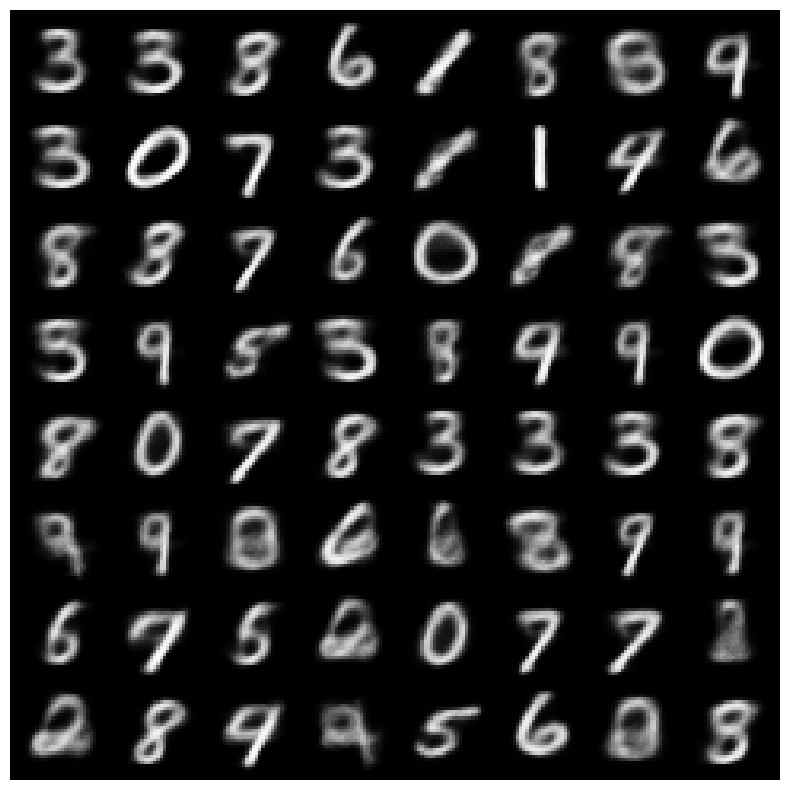

In [31]:
# Visualize sampled digits from our model
decoder.eval()

num_samples = 64
with torch.no_grad():
    z = torch.randn(num_samples, 2)
    expected_xs = decoder.forward(z).mean
    expected_xs = expected_xs.reshape(-1, 28, 28).unsqueeze(1)

# Plot the expected_xs as a grid of images
expected_xs_grid = make_grid(expected_xs, nrow=8)
plt.figure(figsize=(10,10))
plt.axis('off')
plt.imshow(expected_xs_grid.permute(1, 2, 0), vmin=0., vmax=1.)
plt.show()

---

The model generates recognizable digits overall, but it struggles in a few visible ways.

First, many samples are blurry. This is a known limitation of VAEs: the model
optimizes an expected log-likelihood which averages over the decoder distribution, producing outputs that represent a weighted average of plausible reconstructions rather than sharp, committed samples.

Second, the two-dimensional latent space is a significant bottleneck. With only
two dimensions, the model has very limited capacity to encode the full diversity
of the ten digit classes, so some digits come out ambiguous or as hybrids between two classes. You can see this in samples that look like a cross between a 3 and an 8, or between a 1 and a 7.

Third, the model seems to have more trouble with structurally complex digits like 8 and 5, which require the decoder to produce closed loops and curved strokes, compared to simpler digits like 1 and 0 which have less structural variation across writers.

---

### Problem 3e: Visualize the Latent Embeddings

Given $\mathbf{x}$, we can interpret the mean of the approximate posterior $\mathbb{E}_{q_{\boldsymbol{\phi}}(\mathbf{z} \mid \mathbf{x})}[\mathbf{z}]$ as a lower dimensional representation of $\mathbf{x}$. In the code below, we find the mean of the approximate posterior for each of the datapoints in the dataset and then visualize these means with a scatter plot. We color each point according to the label of the encoded digit. What do you notice? Are there classes with significant overlap, and are these classes which are visually similar? Is there a class which has clear separation from the others, and if so, why do you think this is?

Note that we did not provide any information about the class label to either the generative model or the approximate posterior!

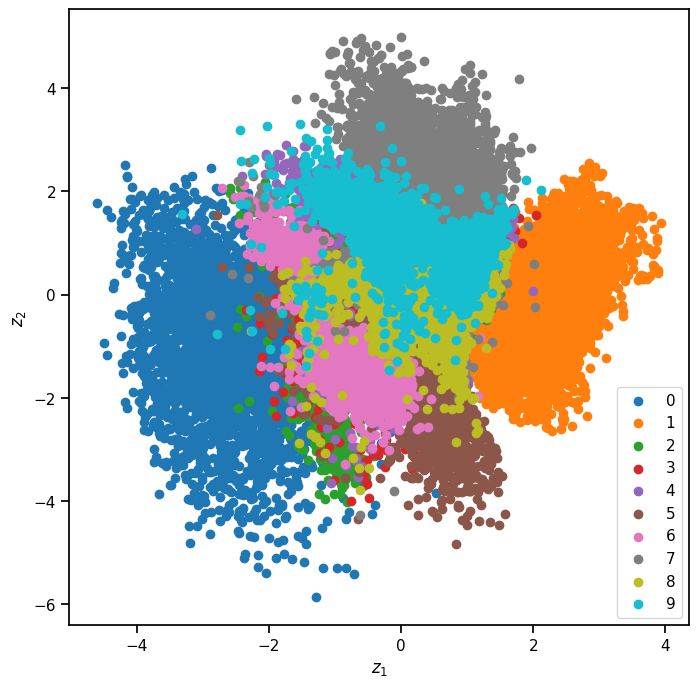

In [32]:
# Compute the mean of the latents given the data
encoder.eval()
with torch.no_grad():
    means = []
    ys = []
    for x, y in train_loader:
        x = binarize(x.reshape(x.shape[0], -1))
        mean = encoder.forward(x).mean
        means.append(mean)
        ys.append(y)

means = torch.vstack(means)
ys = torch.hstack(ys)

# Plot the first two dimensions of the latents
fig, ax = plt.subplots(figsize=(8, 8))
for i in range(10):
    means_i = means[ys == i]
    ax.scatter(means_i[:, 0], means_i[:, 1], label=str(i))

ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')
ax.legend()

---

The latent space shows a clear structure even though the model never had access
to class labels during training.

Digit 1 (orange) has the clearest separation from all other classes, sitting on
the right side of the plot with very little overlap. This makes sense because 1
is structurally the simplest digit, consisting of a single vertical stroke, which is visually distinct from every other digit.

Digit 0 (blue) also has relatively good separation, occupying the bottom left
region. Its circular structure is distinctive enough that the encoder consistently maps it away from the other classes.

The most significant overlap occurs in the center of the plot, where digits 2, 3, 4, 5, 6, 8, and 9 are heavily mixed together. This is expected because these digits share structural elements like curves, loops, and strokes, making them harder to separate in a two-dimensional space.

Digits 7 (gray) and 9 (cyan) show partial separation at the top of the plot but
still overlap with each other and with 4, which is reasonable given their visual
similarity in many handwriting styles.

The fact that any structure emerges at all is remarkable, since the model was only trained to reconstruct images and regularize the latent space toward a standard Gaussian. The class structure is purely a consequence of the data geometry.

---

### Problem 3f: Interpolation in the Latent Space

Another desideratum for a latent variable model is smooth interpolation in the latent space. For example, if we linearly interpolate between a latent $\mathbf{z}_{start}$ corresponding to a $7$ and a latent $\mathbf{z}_{end}$ corresponding to a $1$, we should observe the decodings of the interpolations smoothly change from a $7$ to a $1$.

In the code below, we sample $8$ different starting latent variables and $8$ different ending latent variables from the prior, linearly interpolate between them for $10$ points, then plot the decodings. Does our model smoothly change between decoded digits? Are there digit pairs it was more successful interpolating between?

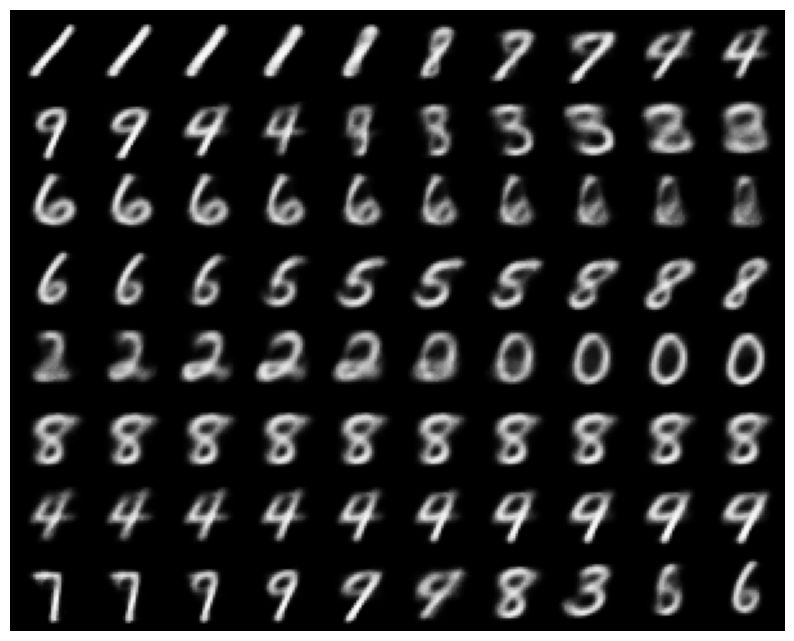

In [33]:
# Interpolate between 8 randomly chosen start and end points
latent_starts = torch.randn(8, 2)
latent_ends = torch.randn(8, 2)

means = []
for t in torch.linspace(0, 1, 10):
    z = latent_starts + t * (latent_ends - latent_starts)
    with torch.no_grad():
        means.append(decoder.forward(z).mean.reshape(-1, 28, 28).unsqueeze(0))

means_tensor=torch.vstack(means).permute(1,0,2,3).reshape(-1,28,28).unsqueeze(1)
sample_grid = make_grid(means_tensor, nrow=10)

plt.figure(figsize=(10,10))
plt.axis('off')
plt.imshow(sample_grid.permute(1, 2, 0).cpu(), vmin=0., vmax=1.)
plt.show()

---

The model interpolates smoothly in most cases. Within each row, the transitions
between digits are gradual, with the stroke structure changing continuously rather
than jumping abruptly, which is a sign that the latent space is well organized.

The most successful interpolations are the ones between visually similar digits.
The transition from 6 to 5 in row four is particularly clean, as both digits share a curved top and the model finds a natural path between them. Similarly, the 2 to 0 transition in row five works well because both have rounded bodies.

The interpolation between 1 and 8 in the first row is the most interesting case.
The strokes of the 1 gradually thicken and develop curves until they close into an 8, passing through what looks like a 7 and then a 4 along the way. This reflects the geometry of the latent space: going from the isolated 1 cluster toward the denser central region forces the decoder to pass through intermediate digit shapes.

The last row is the least clean, showing a transition from 7 through 9, 8, 3, and 6. This corresponds to a path through the heavily overlapping central region of the latent space we saw in 3e, so the lack of a clean transition is expected.

---

## Problem 4: Reflections

### Problem 4a

Discuss one reason why we use amortized variational inference rather than optimizing per-datapoint latent variables $\mu^{(n)}, (\boldsymbol{\sigma}^2)^{(n)}$ (so $p(\mathbf{z^{(n)}} \mid \mathbf{x}^{(n)})= \mathcal{N}(\mathbf{z}^{(n)} \mid \mu^{(n)}, \text{diag}((\boldsymbol{\sigma}^2)^{(n)})$).

---

Amortized variational inference uses a shared encoder network to map any datapoint directly to its approximate posterior parameters, rather than maintaining separate variational parameters for each datapoint. The key advantage is generalization: once the encoder is trained, it can compute the approximate posterior for a new, unseen datapoint in a single forward pass, without requiring any additional optimization.
With per-datapoint variational parameters, every new datapoint would require running a full optimization loop from scratch to find its latent representation.

---

### Problem 4b

Describe one way you could improve the variational autoencoder, either by changing the encoder or decoder network structure or by changing the  model itself, and why you think your proposed change would help.


---

One improvement would be to increase the dimensionality of the latent space from 2 to something larger, like 10 or 20. The two-dimensional constraint was useful for visualization in 3e and 3f, but it is a severe bottleneck for the generative model.
MNIST has ten classes with significant intra-class variation in writing style, stroke width, and orientation. A two-dimensional latent space cannot capture all of this variation simultaneously, which is why the samples in 3d are blurry and many classes overlap in 3e. A higher-dimensional latent space would allow the model to allocate separate dimensions to different sources of variation, producing sharper and more diverse samples.

---

### Problem 4c

Suppose rather than using a Gaussian prior on $\mathbf{z}$, we used $\mathbf{z} \overset{ind}{\sim} \text{Bern}(0.5)$. We can modify $E_{\boldsymbol{\phi}}$ to output logits for a multivariate Bernoulli distribution: $p(\mathbf{z} \mid \mathbf{x}; \boldsymbol{\phi}) = \text{Bern}(\mathbf{z}; \sigma(E_{\boldsymbol{\phi}}(\mathbf{x})))$. Where would our optimization procedure break down in this case?

---

The reparametrization trick would break down. For the Gaussian case, we can write z = mu + epsilon * sigma where epsilon is a continuous noise variable, which makes the sampling operation differentiable with respect to the encoder parameters. For a Bernoulli latent variable, sampling is a discrete operation: it produces a 0 or a 1 with no gradient flowing through. Backpropagating through a discrete sample is not possible with standard automatic differentiation, so we could not optimize the encoder parameters phi using gradient descent on the ELBO.

---

## Submission Instructions

**Formatting:** check that your code does not exceed 80 characters in line width.

Download your notebook in .ipynb format and use the following commands to convert it to PDF. First, rename your file `<yourlastname>_hw7.ipynb`. Then run:
```
jupyter nbconvert --to webpdf <yourlastname>_hw7.ipynb
```

This uses a headless browser to render the notebook as a PDF (no LaTeX installation required). Math is rendered via MathJax, so it should look the same as in the notebook.

**Installing dependencies:**
```
pip install "nbconvert[webpdf]"
playwright install chromium
```

If the above doesn't work, one quick and easy approach is to open it as a Jupyter notebook, print, and save to PDF. Just make sure your LaTeX math answers aren't cut off so we can grade them.

**Upload** your .pdf file to Gradescope. Please tag your questions!

In [34]:
%%capture
!pip install "nbconvert[webpdf]"
!playwright install chromium

In [ ]:
!jupyter nbconvert --to webpdf Paz_hw7.ipynb